In [44]:
import os

In [45]:
DATA_DIR = 'foodsg-233'

In [46]:
num_items = len(os.listdir(DATA_DIR))
print(f"Number of items: {num_items}")

Number of items: 233


## Creating a train and test dataset for fast ai

In [47]:
import shutil
import random
from pathlib import Path
import pandas as pd
import os


# Base paths
src_base = Path(DATA_DIR)
dst_base = Path("foodsg233_fastai_dataset")
train_dir = dst_base / "train"
valid_dir = dst_base / "valid"

train_dir.mkdir(parents=True, exist_ok=True)
valid_dir.mkdir(parents=True, exist_ok=True)

# Parameters
train_split = 0.8  # 80% for training

# Loop through all class folders
for class_dir in src_base.iterdir():
    if not class_dir.is_dir():
        continue  # skip files that are not directories

    class_name = class_dir.name  # folder name is already the class name
    print(f"Processing class: {class_name}")
    
    # Get image files (you can expand extensions if needed)
    img_files = list(class_dir.glob("*.jpg"))
    random.shuffle(img_files)
    
    split_idx = int(len(img_files) * train_split)
    train_imgs = img_files[:split_idx]
    valid_imgs = img_files[split_idx:]
    
    # Create class folders inside train and valid
    (train_dir / class_name).mkdir(parents=True, exist_ok=True)
    (valid_dir / class_name).mkdir(parents=True, exist_ok=True)
    
    # Copy images into split folders
    for img in train_imgs:
        shutil.copy(img, train_dir / class_name / img.name)
    for img in valid_imgs:
        shutil.copy(img, valid_dir / class_name / img.name)

print("✅ Dataset split into train/valid for fastai.")


Processing class: Alcoholic Beverage
Processing class: Apple
Processing class: Apricot
Processing class: assam pedas
Processing class: Avocados
Processing class: ayam penyet
Processing class: bagel & croissant
Processing class: bak chor mee
Processing class: bak kut teh
Processing class: bak kwa
Processing class: baked beans
Processing class: bakso
Processing class: Ban Mian
Processing class: banana
Processing class: Barley
Processing class: bee hoon
Processing class: Bee hoon, goreng
Processing class: Bee hoon, soto
Processing class: beef noodle soup
Processing class: begedil
Processing class: Bibimbap
Processing class: biscuit
Processing class: black pepper crab
Processing class: Blackberry
Processing class: blueberries
Processing class: breakfast cereal
Processing class: Bubble Milk Tea
Processing class: buckwheat
Processing class: Burger
Processing class: cake
Processing class: cake rolls
Processing class: canned Fruit salad
Processing class: cereal prawns
Processing class: chai to

# Working with fast ai 

In [5]:
import torch, platform
print("Torch:", torch.__version__)
print("Built against CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
print("Capability reported by driver ok; PyTorch arch list:", torch.cuda.get_arch_list())


Torch: 2.8.0+cu128
Built against CUDA: 12.8
CUDA available: True
Device: NVIDIA GeForce RTX 5060 Ti
Capability reported by driver ok; PyTorch arch list: ['sm_61', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [6]:
from fastai.vision.all import *

In [7]:
dls = ImageDataLoaders.from_folder(
    Path("fastai_dataset"),
    train='train',
    valid='valid',
    item_tfms=Resize(224),            # Resize all images to 224x224
    batch_tfms=aug_transforms(),      # Apply standard image augmentations
)

TypeError: 'NoneType' object is not iterable

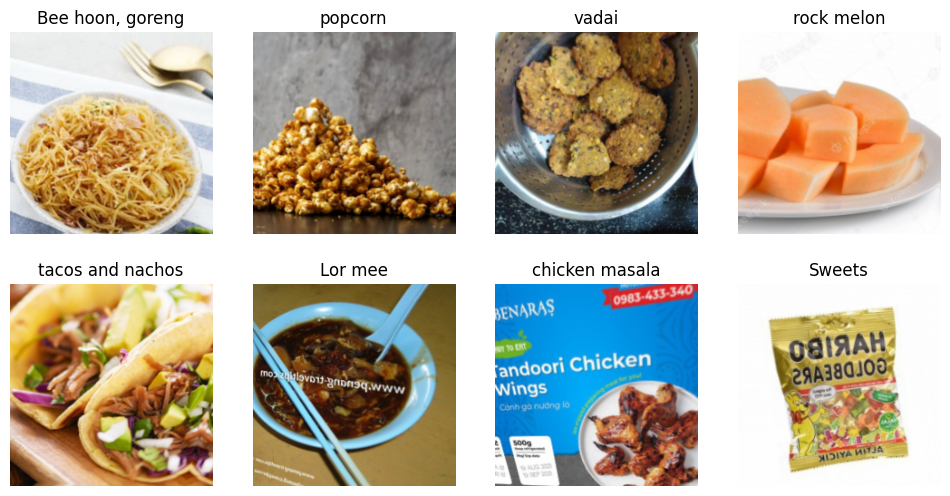

In [5]:
dls.show_batch(max_n=8)

In [6]:
learn = cnn_learner(dls, resnet34, metrics=accuracy)

c:\Users\royli\vscode projects\food image classification\.venv\Lib\site-packages\fastai\vision\learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\royli/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:34<00:00, 2.51MB/s]


In [7]:
learn.fine_tune(5)  # try 5 epochs first, increase later

epoch,train_loss,valid_loss,accuracy,time
0,2.350325,1.810460,0.550030,47:29


epoch,train_loss,valid_loss,accuracy,time
0,1.739997,1.425892,0.637870,35:11
1,1.557991,1.289890,0.670534,34:47
2,1.268797,1.141669,0.703792,34:59
3,1.028771,1.027548,0.733151,35:04
4,0.901692,1.007016,0.739617,35:04


In [8]:
learn.save('resent34_5epochs')

Path('fastai_dataset/models/resent34_5epochs.pth')

In [10]:
learn.export('resent34_5epochs.pkl')

## Resnet 101

In [3]:
from fastai.vision.all import *

c:\Users\royli\vscode projects\food image classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Step 1: Setup DataLoaders
dls = ImageDataLoaders.from_folder(
    Path("fastai_dataset"),
    train='train',
    valid='valid',
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    bs=128
)

In [7]:
from torchvision.models import resnet101
# Step 2: Create a learner using ResNet-101
learn = vision_learner(dls, resnet101, metrics=accuracy)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to C:\Users\royli/.cache\torch\hub\checkpoints\resnet101-cd907fc2.pth


100%|██████████| 171M/171M [01:11<00:00, 2.52MB/s] 


In [8]:
learn.fine_tune(
    20,
    cbs=EarlyStoppingCallback(
        monitor='valid_loss',  # what to monitor ('accuracy', 'valid_loss', etc.)
        patience=3             # stop after 3 epochs with no improvement
    )
)

epoch,train_loss,valid_loss,accuracy,time
0,2.125967,1.655365,0.589445,1:27:29


epoch,train_loss,valid_loss,accuracy,time
0,1.428684,1.152194,0.705218,3:05:20
1,1.209746,1.021547,0.734768,3:06:36
2,1.071334,0.951984,0.750981,3:05:04
3,1.009842,0.928822,0.754974,3:05:15
4,0.946057,0.915517,0.763414,3:05:26
5,0.905802,0.906012,0.767503,3:05:35
6,0.821652,0.915464,0.767764,3:04:59


KeyboardInterrupt: 

In [9]:
learn.save('resent101_6epochs_cp')

Path('fastai_dataset/models/resent101_6epochs_cp.pth')

In [10]:
learn.export('resent101_6epochs_cp.pkl')

## ViT - Vision Transformer (small)

In [10]:
from pathlib import Path
from fastai.vision.all import get_image_files

print(list(Path("foodsg233_fastai_dataset/train").iterdir()))   # should show class folders
print(len(get_image_files(Path("foodsg233_fastai_dataset/train"))))  # should be > 0


[Path('foodsg233_fastai_dataset/train/Alcoholic Beverage'), Path('foodsg233_fastai_dataset/train/Apple'), Path('foodsg233_fastai_dataset/train/Apricot'), Path('foodsg233_fastai_dataset/train/assam pedas'), Path('foodsg233_fastai_dataset/train/Avocados'), Path('foodsg233_fastai_dataset/train/ayam penyet'), Path('foodsg233_fastai_dataset/train/bagel & croissant'), Path('foodsg233_fastai_dataset/train/bak chor mee'), Path('foodsg233_fastai_dataset/train/bak kut teh'), Path('foodsg233_fastai_dataset/train/bak kwa'), Path('foodsg233_fastai_dataset/train/baked beans'), Path('foodsg233_fastai_dataset/train/bakso'), Path('foodsg233_fastai_dataset/train/Ban Mian'), Path('foodsg233_fastai_dataset/train/banana'), Path('foodsg233_fastai_dataset/train/Barley'), Path('foodsg233_fastai_dataset/train/bee hoon'), Path('foodsg233_fastai_dataset/train/Bee hoon, goreng'), Path('foodsg233_fastai_dataset/train/Bee hoon, soto'), Path('foodsg233_fastai_dataset/train/beef noodle soup'), Path('foodsg233_fastai_

In [26]:
from fastai.vision.all import *

dls = ImageDataLoaders.from_folder(
    Path("foodsg233_fastai_dataset"),
    train='train',
    valid='valid',
    item_tfms=Resize(224),          # Can increase to 384 for ViT if you have VRAM
    batch_tfms=aug_transforms(),
    bs=64                           # Lower if you get OOM errors
)


In [28]:
learn = vision_learner(
    dls,
    'vit_small_patch16_224',         # Replace with any ViT model name from timm
    pretrained=True,
    metrics=accuracy
)


In [3]:
learn.fine_tune(
    5,
    cbs=EarlyStoppingCallback(monitor='valid_loss', patience=3)
)


epoch,train_loss,valid_loss,accuracy,time
0,1.456073,1.070278,0.720623,36:42


epoch,train_loss,valid_loss,accuracy,time
0,1.188519,0.896458,0.762938,38:57
1,1.089779,0.847504,0.775704,38:51
2,0.979752,0.792024,0.789088,38:42
3,0.878454,0.757422,0.798027,38:17
4,0.822646,0.750431,0.801284,38:32


In [4]:
learn.save('vit_small_5epochs')

Path('fastai_dataset/models/vit_small_5epochs.pth')

In [5]:
learn.export('vit_small_5epochs.pkl')

## ViT - tuning

### confusion matrix

In [35]:
learn = load_learner('foodsg233_fastai_dataset/vit_small_5epochs.pkl')

preds, targs = learn.get_preds()

c:\Users\royli\vscode projects\food image classification\.venv\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [36]:
interp = ClassificationInterpretation.from_learner(learn)


In [37]:
interp.plot_confusion_matrix(figsize=(12,12), dpi=100)


ValueError: not enough values to unpack (expected 3, got 2)

In [24]:
interp.most_confused(min_val=5)


KeyboardInterrupt: 

In [ ]:
# example output:

[('laksa', 'curry noodles', 12),
 ('fried rice', 'nasi goreng', 8),
 ('ramen', 'udon', 7)]

→ means the model often mistakes laksa for curry noodles (12 times).

In [ ]:
## per class accuracy

import pandas as pd
preds, targs = learn.get_preds()
pred_labels = preds.argmax(dim=1)

# per-class accuracy
accs = []
for i, cls in enumerate(dls.vocab):
    mask = targs == i
    correct = (pred_labels[mask] == i).float().mean().item() if mask.sum() > 0 else None
    accs.append((cls, correct))

df = pd.DataFrame(accs, columns=["class", "accuracy"]).sort_values("accuracy")
print(df.head(10))   # 10 worst-performing classes

In [ ]:
## top loss visualisation
interp.plot_top_losses(9, nrows=3)


## Export as ONNX

In [5]:
from fastai.vision.all import *

learn = load_learner("fastai_dataset/vit_small_5epochs.pkl")

In [6]:
model = learn.model
model.eval()

Sequential(
  (0): TimmBody(
    (model): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=384, out_features=1152, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): L

In [7]:
import torch

dummy_input = torch.randn(1, 3, 224, 224)  # batch size 1, 3-channel RGB image

In [10]:
torch.onnx.export(
    model,
    dummy_input,
    "vit_small.onnx",
    export_params=True,
    opset_version=17,  # <-- critical change from 11 to 17
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)


C:\Users\royli\AppData\Local\Temp\ipykernel_15412\2013418588.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


In [38]:
# Load the vit_small_5epochs model from foodsg233_fastai_dataset
from fastai.vision.all import *
import torch

# Load the saved model
learn = load_learner("foodsg233_fastai_dataset/vit_small_5epochs.pkl")
print("✅ Successfully loaded vit_small_5epochs model")
print(f"Model architecture: {learn.arch}")
print(f"Number of classes: {len(learn.dls.vocab)}")
print(f"Classes: {learn.dls.vocab[:10]}...")  # Show first 10 classes

✅ Successfully loaded vit_small_5epochs model
Model architecture: vit_small_patch16_224
Number of classes: 233
Classes: ['Alcoholic Beverage', 'Apple', 'Apricot', 'Avocados', 'Ban Mian', 'Barley', 'Bee hoon, goreng', 'Bee hoon, soto', 'Bibimbap', 'Blackberry']...


In [39]:
# Load the dataset to analyze the model performance
from pathlib import Path

# Set up DataLoaders with the same configuration used for training
dls = ImageDataLoaders.from_folder(
    Path("foodsg233_fastai_dataset"),
    train='train',
    valid='valid',
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    bs=64
)

# Update the learner with the correct data loaders
learn.dls = dls

print("✅ Data loaders set up successfully")
print(f"Training samples: {len(dls.train_ds)}")
print(f"Validation samples: {len(dls.valid_ds)}")
print(f"Batch size: {dls.bs}")
print(f"Image size: 224x224")

✅ Data loaders set up successfully
Training samples: 167796
Validation samples: 42065
Batch size: 64
Image size: 224x224


In [40]:
# Get model validation metrics
print("🔍 Analyzing model performance...")

# Get validation loss and accuracy
interp = ClassificationInterpretation.from_learner(learn)
print(f"✅ Interpretation created successfully")

# Show current accuracy
val_loss, val_acc = learn.validate()
print(f"📊 Current Performance:")
print(f"   Validation Loss: {val_loss:.4f}")
print(f"   Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

🔍 Analyzing model performance...


✅ Interpretation created successfully


📊 Current Performance:
   Validation Loss: 0.8409
   Validation Accuracy: 0.7754 (77.54%)


🔍 Top losses (worst predictions):


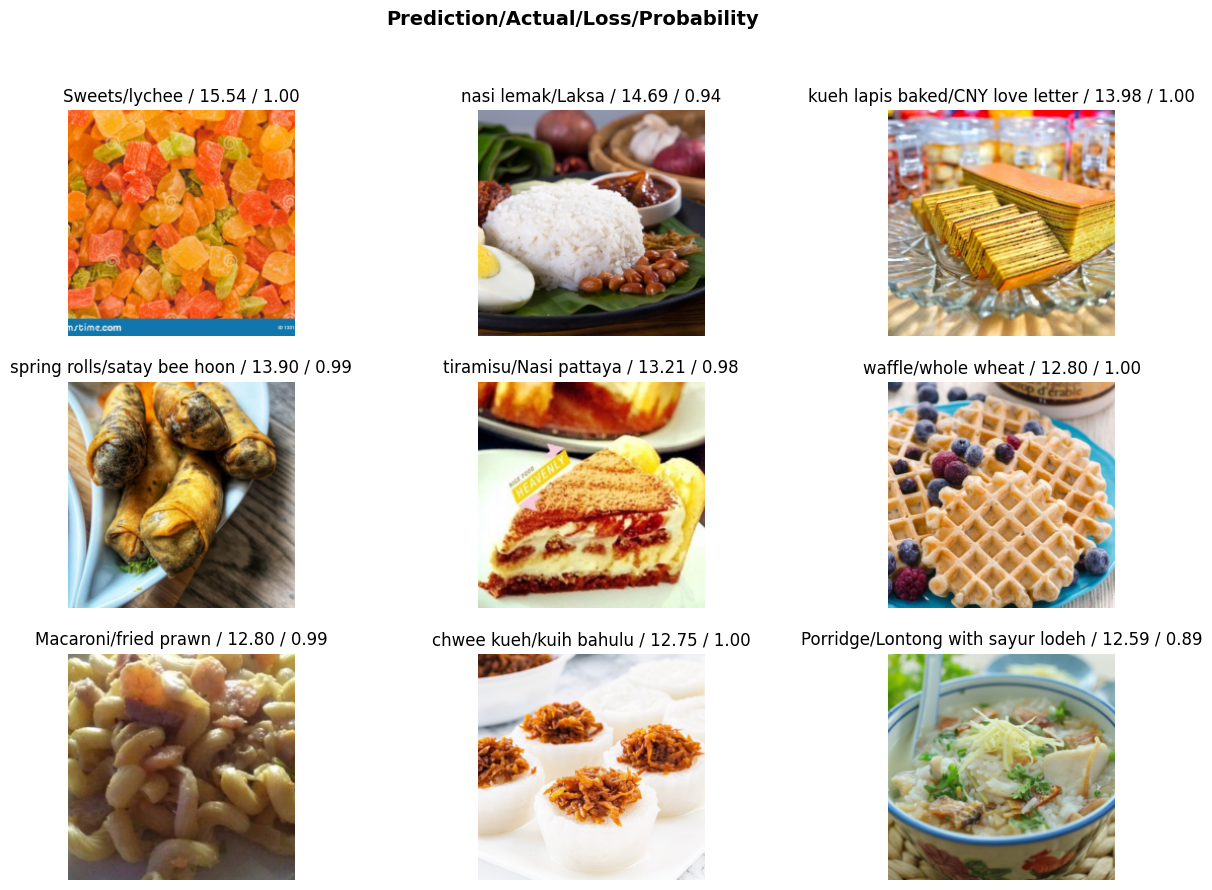

In [41]:
# Show top losses - images that the model gets most wrong
print("🔍 Top losses (worst predictions):")
interp.plot_top_losses(9, figsize=(15,10))

📊 Plotting confusion matrix...


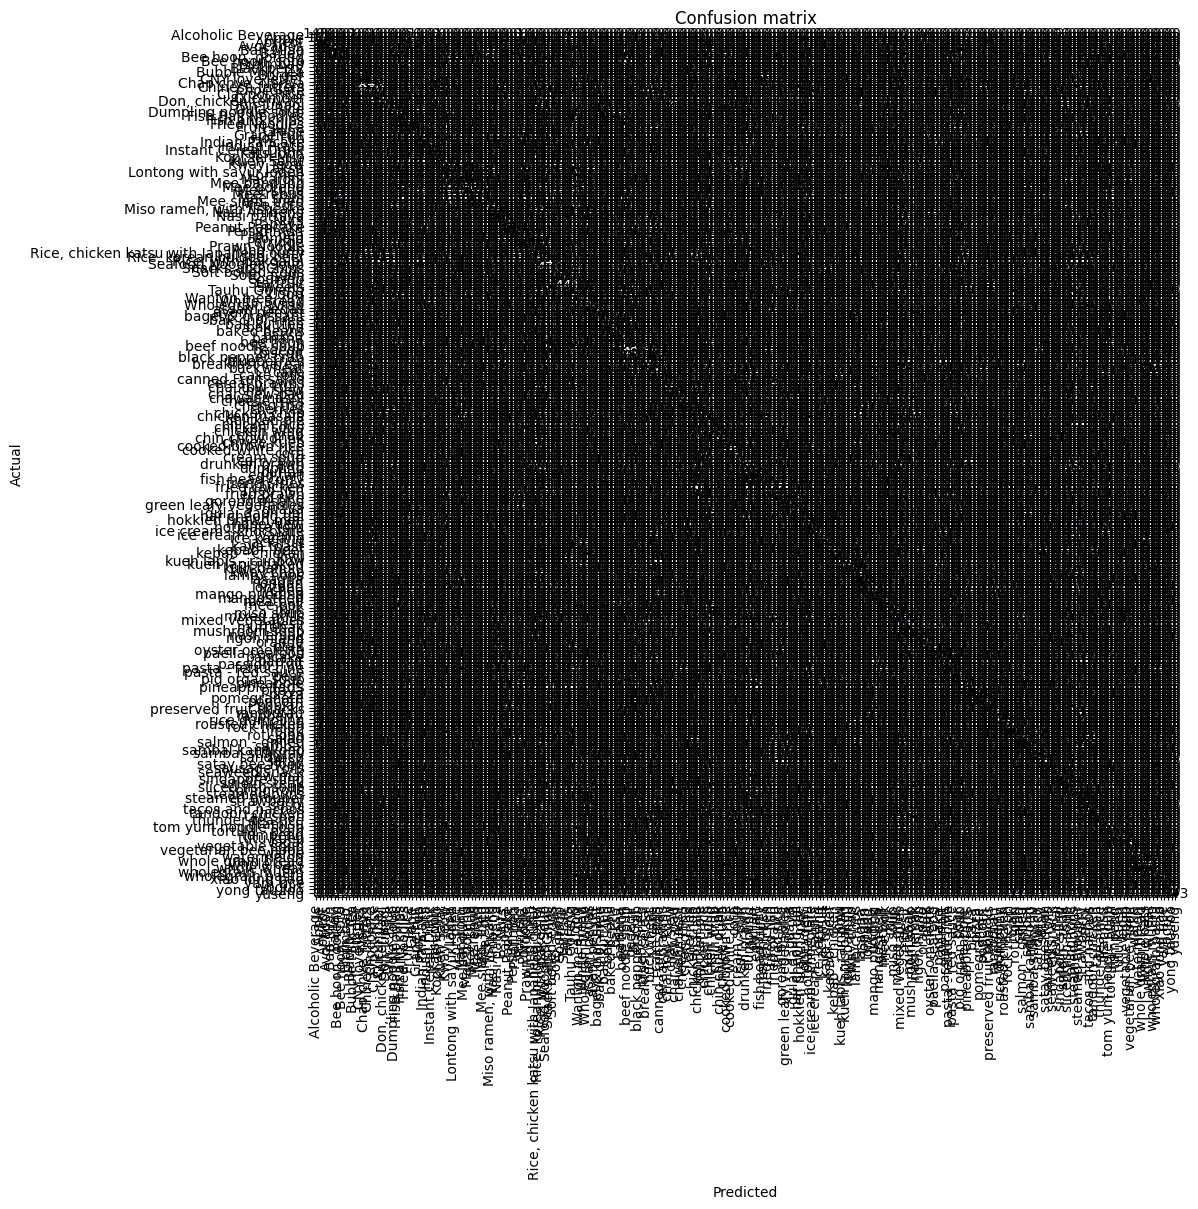

In [42]:
# Get confusion matrix to understand class-wise performance
print("📊 Plotting confusion matrix...")
interp.plot_confusion_matrix(figsize=(12,12), dpi=100)

In [43]:
# Get the most confused classes
print("🔄 Most confused classes:")
most_confused = interp.most_confused(min_val=2)
for item in most_confused[:10]:  # Show top 10
    print(f"   {item[0]} → {item[1]}: {item[2]} errors")

🔄 Most confused classes:


   char siew pau → steamed buns: 67 errors
   lontong → Lontong with sayur lodeh: 55 errors
   Sweets → Chocolate: 47 errors
   breakfast cereal → muesli: 47 errors
   Bee hoon, goreng → bee hoon: 46 errors
   Mee siam, fried → Bee hoon, goreng: 46 errors
   whole wheat → whole grain bread: 44 errors
   vegetable soup → chicken soup: 39 errors
   Mee soto → Soto ayam: 37 errors
   Bee hoon, soto → Mee soto: 35 errors
